In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
Psi = np.array([
    [1, 0],
    [0, 1],
    [1, 1]
])
Y = np.array([1, 5, 2])

### Пункт а. Уравнение линейной регрессии

In [4]:
F = Psi.T @ Psi
F_inv = np.linalg.inv(F)

beta = F_inv @ Psi.T @ Y
print(beta)

[-0.33333333  3.66666667]


### Пункт б. Уравнение ridge регрессии

In [ ]:
def ridge_loss(beta, Psi, Y, l):
    e = Y - Psi @ beta
    return e @ e + l * (beta @ beta)

def cvss_lambda_ridge(Psi, Y, n_points=200):
    n, _ = Psi.shape
    cvss_list = np.zeros(n_points)
    lambda_linspace = np.linspace(0, 10, n_points)
    for idx, l in enumerate(lambda_linspace): 
        cvss = 0
        for i in range(n):

            Psi_test = Psi[i]
            Y_test = Y[i]
            Psi_train = np.delete(Psi, i, axis = 0)
            Y_train = np.delete(Y, i, axis=0)

            res = minimize(ridge_loss, x0=np.zeros(Psi_train.shape[1]), 
                           args=(Psi_train, Y_train, l), method='BFGS')
            min_b1_b2 = res.x
            Y_pred = Psi_test @ min_b1_b2
            cvss+=(Y_pred - Y_test)**2
        cvss_list[idx] = cvss
    min_cvss_idx = np.argmin(cvss_list)
    lambda_result = lambda_linspace[min_cvss_idx]
    return lambda_linspace, cvss_list, lambda_result

lambda_linspace, cvss_list, lambda_result = cvss_lambda(Psi, Y, 1000)
print(f"Итоговая лямбдочка: {lambda_result}")

Итоговая лямбдочка: 1.5015015015015014


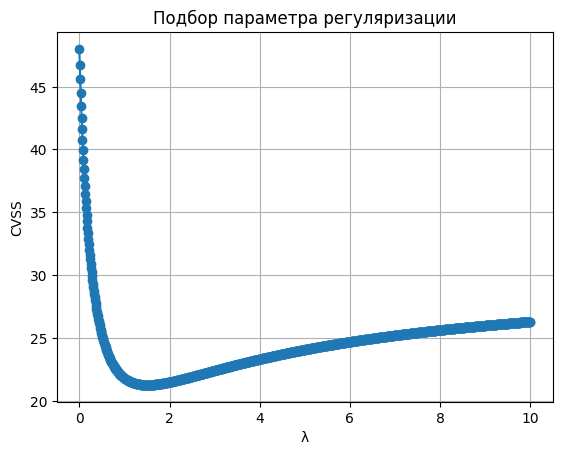

In [60]:
def build_plot_cvss_lambda():
    plt.plot(lambda_linspace, cvss_list, marker='o')
    plt.xlabel('λ')
    plt.ylabel('CVSS')
    plt.title('Подбор параметра регуляризации')
    plt.grid()
    plt.show()
build_plot_cvss_lambda()

In [61]:
def ridge_regression(Psi, Y):
    res = minimize(ridge_loss, x0=np.zeros(Psi.shape[1]), 
                           args=(Psi, Y, lambda_result), method='BFGS')
    min_b1_b2 = res.x
    print(f"w = {min_b1_b2[0]:.3f} * ksi + {min_b1_b2[1]:.3f} * eta")
ridge_regression(Psi, Y)

w = 0.311 * ksi + 1.910 * eta


### lasso регрессия

In [70]:
def g(beta):
    return np.sum(np.abs(beta))

def lasso_loss(beta, Psi, Y, l):
    e = Y - Psi @ beta
    return e @ e + l * g(beta)

def cvss_lambda_lasso(Psi, Y, n_points=200):
    n, _ = Psi.shape
    cvss_list = np.zeros(n_points)
    lambda_linspace = np.linspace(0, 10, n_points)
    
    for idx, l in enumerate(lambda_linspace): 
        cvss = 0
        for i in range(n):
            Psi_test = Psi[i]
            Y_test = Y[i]
            Psi_train = np.delete(Psi, i, axis=0)
            Y_train = np.delete(Y, i, axis=0)

            res = minimize(lasso_loss, x0=np.zeros(Psi_train.shape[1]), 
                           args=(Psi_train, Y_train, l), method='Nelder-Mead')
            min_beta = res.x
            Y_pred = Psi_test @ min_beta
            cvss += (Y_pred - Y_test)**2
        cvss_list[idx] = cvss
        
    min_cvss_idx = np.argmin(cvss_list)
    lambda_result = lambda_linspace[min_cvss_idx]
    return lambda_linspace, cvss_list, lambda_result

lambda_linspace, cvss_list, lambda_result = cvss_lambda_lasso(Psi, Y, 200)
print(f"Итоговая лямбдочка (Lasso): {lambda_result}")

Итоговая лямбдочка (Lasso): 5.9798994974874375


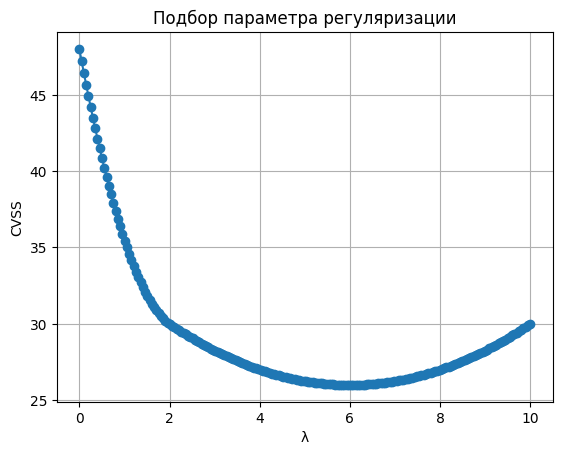

In [71]:
def build_plot_cvss_lambda():
    plt.plot(lambda_linspace, cvss_list, marker='o')
    plt.xlabel('λ')
    plt.ylabel('CVSS')
    plt.title('Подбор параметра регуляризации')
    plt.grid()
    plt.show()
build_plot_cvss_lambda()

In [73]:
def lasso_regression(Psi, Y):
    res = minimize(lasso_loss, x0=np.zeros(Psi.shape[1]), 
                           args=(Psi, Y, lambda_result), method='Nelder-Mead')
    min_b1_b2 = res.x
    print(f"w = {min_b1_b2[0]:.3f} * ksi + {min_b1_b2[1]:.3f} * eta")
lasso_regression(Psi, Y)

w = 0.000 * ksi + 2.005 * eta
